In [42]:
# Import torch
import torch

# Setup random seed
RANDOM_SEED = 42

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

#### 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.
  * For consistency, the dataset should have 1000 samples and a `random_state=42`.
  * Turn the data into PyTorch tensors.
  * Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.

In [65]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons

n_samples = 1000
X, y = make_moons(n_samples=n_samples, noise=0.05, random_state=RANDOM_SEED)

print(f"First 5 X features:\n{X[:5]}", "\n")
print(f"First 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.02137124  0.40618608]
 [ 0.97670045 -0.45832306]
 [ 0.90405882 -0.37651952]
 [ 0.37736316 -0.39703717]
 [-0.84192557  0.53058695]] 

First 5 y labels:
[1 1 1 1 0]


In [66]:
# Turn data into a DataFrame
import pandas as pd

moons = pd.DataFrame({
    "X1": X[:, 0],
    "X2": X[:, 1],
    "y": y
})
moons.head()


,X1,X2,y
0,-0.021371,0.406186,1
1,0.976700,-0.458323,1
2,0.904059,-0.376520,1
3,0.377363,-0.397037,1
4,-0.841926,0.530587,0


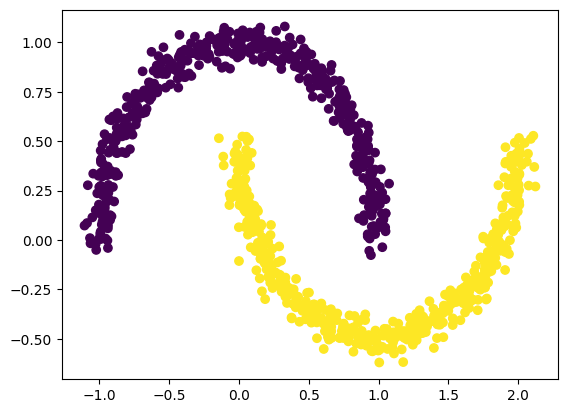

In [67]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt
plt.scatter(
    x = X[:, 0],
    y = X[:, 1],
    c = y,
)

In [68]:
# Turn data into tensors of dtype float
X = torch.tensor(X, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float)

# Split the data into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=RANDOM_SEED)

#### 2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
  * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [69]:
import torch
from torch import nn

# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
    def __init__(self, in_features, out_features, hidden_units):
        super().__init__()

        self.layer1 = nn.Linear(in_features=in_features,
                                 out_features=hidden_units)
        self.layer2 = nn.Linear(in_features=hidden_units,
                                 out_features=hidden_units)
        self.layer3 = nn.Linear(in_features=hidden_units,
                                out_features=out_features)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

modelV0 = MoonModelV0(in_features=2, out_features=1, hidden_units=10).to(device)
modelV0

MoonModelV0(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

#### 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [70]:
# Setup loss function
loss_func = nn.BCEWithLogitsLoss()

# Setup optimizer to optimize model's parameters
optimizer = torch.optim.SGD(params=modelV0.parameters(), lr=0.1)

#### 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
  * Do a forward pass of the model to see what's coming out in the form of logits, prediction probabilities and labels.
  * To measure model accuray, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).
  * Train the model for long enough for it to reach over 96% accuracy.
  * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [73]:
# What's coming out of our model?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


# logits (raw outputs of model)
print("Logits:")
y_log = modelV0(X_test.to(device))[:5]
print(y_log)

# Prediction probabilities
print("Pred probs:")
y_pred_probs = torch.sigmoid(y_log)
print(y_pred_probs)

# Prediction labels
print("Pred labels:")
y_pred_labels = torch.round(torch.sigmoid(modelV0(X_test.to(device))[:5]))
print(y_pred_labels)

Logits:
tensor([[-0.0747],
        [-0.0560],
        [-0.1641],
        [-0.0438],
        [-0.2220]], device='cuda:0', grad_fn=<SliceBackward0>)
Pred probs:
tensor([[0.4813],
        [0.4860],
        [0.4591],
        [0.4890],
        [0.4447]], device='cuda:0', grad_fn=<SigmoidBackward0>)
Pred labels:
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0', grad_fn=<RoundBackward0>)


In [75]:
# Let's calculuate the accuracy using accuracy from TorchMetrics
!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: Uncomment this code to use the Accuracy function
acc_fn = Accuracy(task="multiclass", num_classes=2).to(device)
acc_fn

MulticlassAccuracy()

In [76]:
## TODO: Uncomment this to set the seed
torch.manual_seed(RANDOM_SEED)

# Setup epochs
epochs = 1000

# Send data to the device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Loop through the data
for epoch in range(epochs):
  ### Training
  modelV0.train()

  # 1. Forward pass (logits output)
  y_logist = modelV0(X_train).squeeze()
  # Turn logits into prediction probabilities
  y_pred = torch.round(torch.sigmoid(y_logist))
  # Turn prediction probabilities into prediction labels
  y_pred_labels = torch.round(torch.sigmoid(modelV0(X_test.to(device))))

  # 2. Calculaute the loss
  loss = loss_func(y_logist, y_train) # loss = compare model raw outputs to desired model outputs
  # Calculate the accuracy
  acc = acc_fn(y_pred, y_train.int()) # the accuracy function needs to compare pred labels (not logits) with actual labels

  # 3. Zero the gradients
  optimizer.zero_grad()

  # 4. Loss backward (perform backpropagation)
  loss.backward()

  # 5. Step the optimizer (gradient descent)
  optimizer.step()

  ### Testing
  modelV0.eval()
  with torch.inference_mode():
    # 1. Forward pass (to get the logits)
    test_logits = modelV0(X_test).squeeze()
    # Turn the test logits into prediction labels
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Caculate the test loss/acc
    test_loss = loss_func(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  # Print out what's happening every 100 epochs
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.72303, Accuracy: 0.28% | Test loss: 0.71843, Test acc: 32.00%
Epoch: 100 | Loss: 0.46806, Accuracy: 0.80% | Test loss: 0.48542, Test acc: 75.00%
Epoch: 200 | Loss: 0.25444, Accuracy: 0.88% | Test loss: 0.26263, Test acc: 87.50%
Epoch: 300 | Loss: 0.21710, Accuracy: 0.90% | Test loss: 0.21611, Test acc: 90.50%
Epoch: 400 | Loss: 0.19515, Accuracy: 0.91% | Test loss: 0.19246, Test acc: 91.50%
Epoch: 500 | Loss: 0.16568, Accuracy: 0.93% | Test loss: 0.16256, Test acc: 92.50%
Epoch: 600 | Loss: 0.12801, Accuracy: 0.94% | Test loss: 0.12481, Test acc: 95.00%
Epoch: 700 | Loss: 0.08929, Accuracy: 0.97% | Test loss: 0.08564, Test acc: 98.00%
Epoch: 800 | Loss: 0.05346, Accuracy: 0.99% | Test loss: 0.04937, Test acc: 99.50%
Epoch: 900 | Loss: 0.03250, Accuracy: 1.00% | Test loss: 0.02975, Test acc: 100.00%


#### 5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.

In [77]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

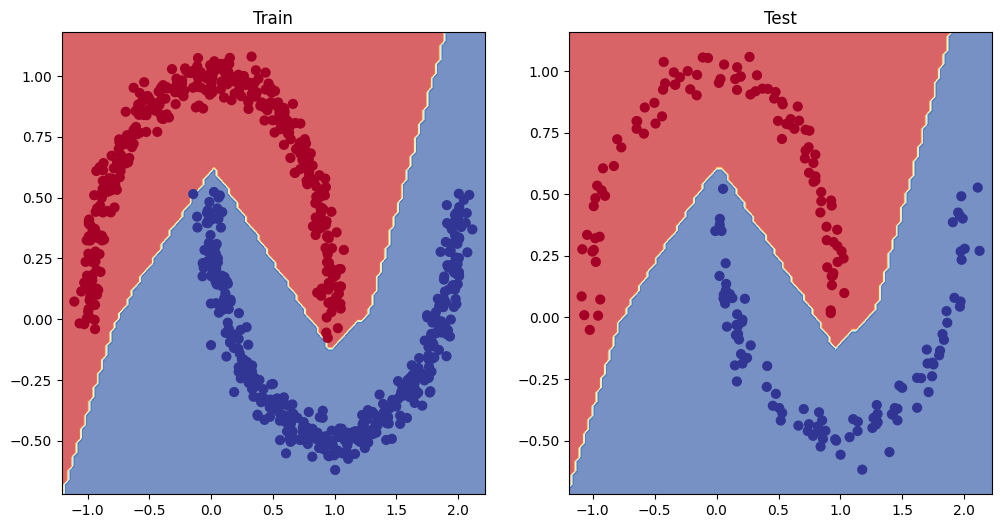

In [78]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelV0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelV0, X_test, y_test)

#### 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
  * [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh)

In [79]:
# Create a straight line tensor
x = torch.linspace(-5, 5, 50)

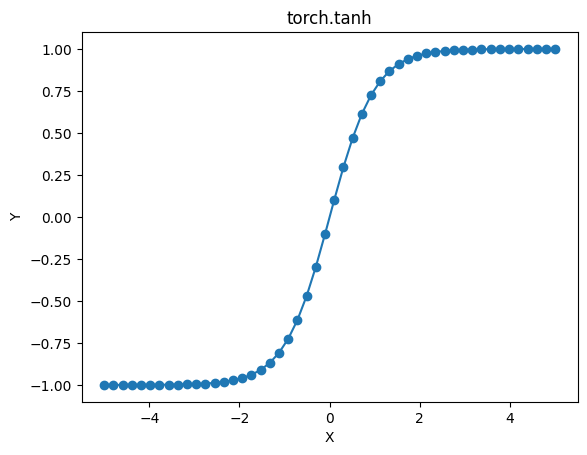

In [80]:

# Test torch.tanh() on the tensor and plot it
b = torch.tanh(x)

plt.plot(x.numpy(), b.numpy(), marker = "o")
plt.title("torch.tanh")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

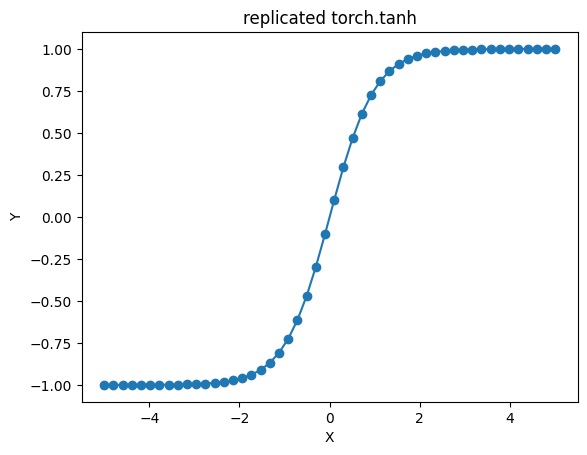

In [81]:
# Replicate torch.tanh() and plot it
#formula: tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))
tanh_custom = (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

plt.plot(x.numpy(), tanh_custom.numpy(), marker="o")
plt.title("replicated torch.tanh")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

#### 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/).
  * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
  * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
  * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
  * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like) - 1000 epochs should be plenty.
  * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.

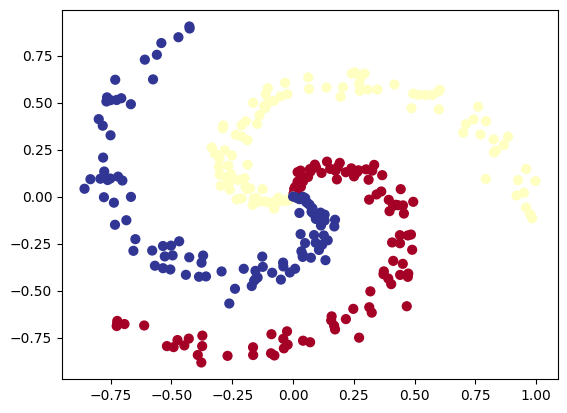

In [82]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels

for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j

# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [83]:
# Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=RANDOM_SEED)

In [84]:
# Let's calculuate the accuracy for when we fit our model
!pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: uncomment the two lines below to send the accuracy function to the device
acc_fn = Accuracy(task="multiclass", num_classes=4).to(device)
acc_fn

MulticlassAccuracy()

In [90]:
# Prepare device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create model by subclassing nn.Module
class Model2(nn.Module):
    def __init__(self):
      super().__init__()
      self.layer1 = nn.Linear(in_features=2, out_features=5)
      self.layer2 = nn.Linear(in_features=5, out_features=5)
      self.layer3 = nn.Linear(in_features=5, out_features=3)
      self.relu = nn.ReLU()

    def forward(self, x):
      return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

# Instantiate model and send it to device
model2 = Model2().to(device)
model2

Model2(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=5, bias=True)
  (layer3): Linear(in_features=5, out_features=3, bias=True)
  (relu): ReLU()
)

In [91]:
# Setup data to be device agnostic
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Print out first 10 untrained model outputs (forward pass)
print("Logits:")
y_log = model2(X_train)[:10]
print(y_log)

print("Pred probs:")
y_pred_probs = torch.softmax(model2(X_train)[:10], dim=1)
print(y_pred_probs)

print("Pred labels:")
y_pred_labels = torch.softmax(model2(X_train)[:10], dim=1).argmax(dim=1)
print(y_pred_labels)

Logits:
tensor([[-0.3030, -0.3070, -0.2609],
        [-0.3042, -0.3082, -0.2620],
        [-0.3030, -0.3070, -0.2609],
        [-0.3030, -0.3070, -0.2609],
        [-0.3030, -0.3070, -0.2609],
        [-0.3030, -0.3070, -0.2609],
        [-0.3030, -0.3070, -0.2609],
        [-0.3060, -0.3100, -0.2637],
        [-0.3030, -0.3070, -0.2609],
        [-0.3030, -0.3070, -0.2609]], device='cuda:0',
       grad_fn=<SliceBackward0>)
Pred probs:
tensor([[0.3290, 0.3278, 0.3432],
        [0.3290, 0.3277, 0.3432],
        [0.3290, 0.3278, 0.3432],
        [0.3290, 0.3278, 0.3432],
        [0.3290, 0.3278, 0.3432],
        [0.3290, 0.3278, 0.3432],
        [0.3290, 0.3278, 0.3432],
        [0.3290, 0.3277, 0.3433],
        [0.3290, 0.3278, 0.3432],
        [0.3290, 0.3278, 0.3432]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Pred labels:
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')


In [92]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.02)

In [93]:
# Build a training loop for the model
epochs = 1000

# Loop over data
for epoch in range(epochs):
  ## Training
  model2.train()
  # 1. Forward pass
  y_logits = model2(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  # 2. Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ## Testing
  model2.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model2(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    # 2. Caculate loss and acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_pred, y_test)
  # Print out what's happening every 100 epochs
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.2f} Acc: {acc:.2f} | Test loss: {test_loss:.2f} Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 1.10 Acc: 0.32 | Test loss: 1.10 Test acc: 0.37
Epoch: 100 | Loss: 0.69 Acc: 0.56 | Test loss: 0.68 Test acc: 0.52
Epoch: 200 | Loss: 0.66 Acc: 0.57 | Test loss: 0.65 Test acc: 0.53
Epoch: 300 | Loss: 0.65 Acc: 0.57 | Test loss: 0.65 Test acc: 0.53
Epoch: 400 | Loss: 0.65 Acc: 0.56 | Test loss: 0.65 Test acc: 0.53
Epoch: 500 | Loss: 0.65 Acc: 0.56 | Test loss: 0.65 Test acc: 0.53
Epoch: 600 | Loss: 0.65 Acc: 0.56 | Test loss: 0.64 Test acc: 0.53
Epoch: 700 | Loss: 0.65 Acc: 0.56 | Test loss: 0.64 Test acc: 0.53
Epoch: 800 | Loss: 0.65 Acc: 0.56 | Test loss: 0.65 Test acc: 0.53
Epoch: 900 | Loss: 0.65 Acc: 0.56 | Test loss: 0.64 Test acc: 0.53


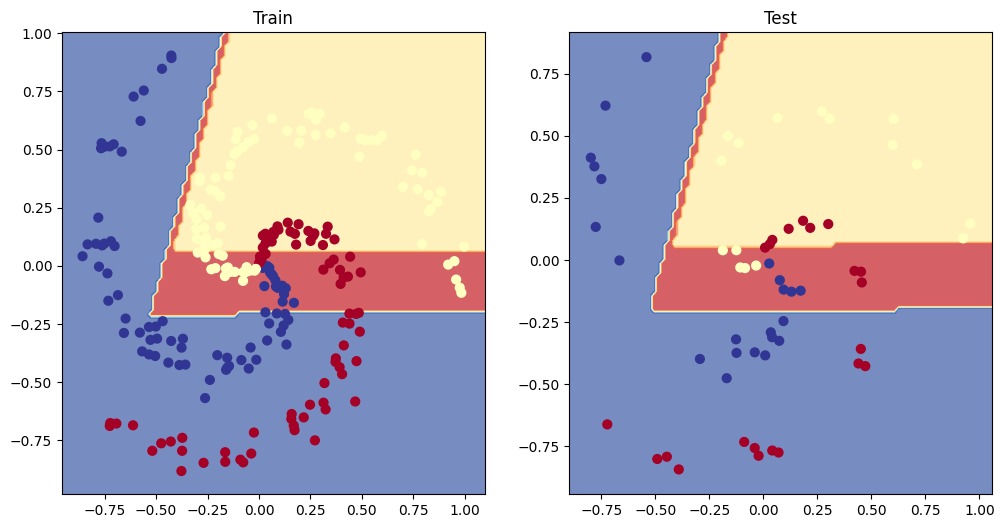

In [95]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model2, X_test, y_test)